In [91]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn.functional as F
import os
from tqdm import tqdm
import time


In [46]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [47]:
# Data preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

batch_size = 128

In [48]:
# Load CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)


Loading CIFAR-10 dataset...


In [49]:
# VAE Model with proper Gaussian latent space
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), # 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 128x4x4
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), # 256x2x2
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Flatten()
        )

        # Mean and variance for Gaussian latent space
        self.fc_mu = nn.Linear(256*2*2, latent_dim)
        self.fc_logvar = nn.Linear(256*2*2, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 256*2*2)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 2, 2)),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 128x4x4
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), # 64x8x8
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), # 32x16x16
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), # 3x32x32
            nn.Tanh()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [50]:
# DCGAN-style Generator and Discriminator
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim

        self.main = nn.Sequential(
            # Input: latent_dim x 1 x 1
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 256 x 4 x 4
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 128 x 8 x 8
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # 64 x 16 x 16
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
            # 3 x 32 x 32
        )

    def forward(self, input):
        input = input.view(-1, self.latent_dim, 1, 1)
        return self.main(input)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.main = nn.Sequential(
            # Input: 3 x 32 x 32
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 64 x 16 x 16
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 128 x 8 x 8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # 256 x 4 x 4
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1)

In [51]:
# Initialize models
latent_dim = 128
vae = VAE(latent_dim=latent_dim).to(device)
generator = Generator(latent_dim=latent_dim).to(device)
discriminator = Discriminator().to(device)

In [52]:
# VAE Loss function with proper reconstruction + KL divergence
def vae_loss(recon_x, x, mu, logvar):
    reconstruction_loss = nn.MSELoss(reduction='sum')(recon_x, x)
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return reconstruction_loss + kl_divergence, reconstruction_loss, kl_divergence

In [53]:
# Training function for VAE with proper monitoring
def train_vae(epochs=20):
    # Clear any previous model states
    vae.apply(weight_reset)

    vae.train()
    optimizer = optim.Adam(vae.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    train_losses = []
    recon_losses = []
    kl_losses = []

    print(f"Training VAE for {epochs} epochs...")

    for epoch in range(epochs):
        epoch_start_time = time.time()
        total_loss = 0
        total_recon = 0
        total_kl = 0
        num_batches = 0

        pbar = tqdm(train_loader, desc=f'VAE Epoch {epoch+1}/{epochs}')

        for i, (data, _) in enumerate(pbar):
            data = data.to(device)
            optimizer.zero_grad()

            recon_batch, mu, logvar = vae(data)
            loss, recon_loss, kl_loss = vae_loss(recon_batch, data, mu, logvar)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()
            num_batches += 1

            if i % 20 == 0:
                pbar.set_postfix({
                    'Total Loss': f'{loss.item()/len(data):.2f}',
                    'Recon': f'{recon_loss.item()/len(data):.2f}',
                    'KL': f'{kl_loss.item()/len(data):.2f}'
                })

        scheduler.step()

        avg_loss = total_loss / len(train_loader.dataset)
        avg_recon = total_recon / len(train_loader.dataset)
        avg_kl = total_kl / len(train_loader.dataset)

        train_losses.append(avg_loss)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)

        epoch_time = time.time() - epoch_start_time
        print(f'VAE Epoch {epoch+1}/{epochs} - Time: {epoch_time:.2f}s')
        print(f'  Average Loss: {avg_loss:.2f}, Recon: {avg_recon:.2f}, KL: {avg_kl:.2f}')

        # Generate sample reconstructions every 5 epochs
        if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
            with torch.no_grad():
                sample = data[:8]
                recon, _, _ = vae(sample)
                comparison = torch.cat([sample, recon])
                vutils.save_image(comparison.cpu(),
                                f'vae_reconstruction_epoch_{epoch+1}.png',
                                nrow=8, normalize=True)

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.plot(train_losses)
    plt.title('VAE Total Loss')
    plt.subplot(1, 3, 2)
    plt.plot(recon_losses)
    plt.title('Reconstruction Loss')
    plt.subplot(1, 3, 3)
    plt.plot(kl_losses)
    plt.title('KL Divergence')
    plt.tight_layout()
    plt.savefig('vae_training_history.png')
    plt.show()

    return vae, train_losses, recon_losses, kl_losses


In [54]:
# Training function for GAN with proper monitoring
def train_gan(epochs=50):
    # Clear any previous model states
    generator.apply(weight_reset)
    discriminator.apply(weight_reset)

    generator.train()
    discriminator.train()

    g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.00002, betas=(0.5, 0.999))

    criterion = nn.BCELoss()

    g_losses = []
    d_losses = []
    real_scores = []
    fake_scores = []

    # Fixed noise for monitoring progress
    fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

    print(f"Training GAN for {epochs} epochs...")

    for epoch in range(epochs):
        epoch_start_time = time.time()
        g_loss_sum = 0
        d_loss_sum = 0
        real_score_sum = 0
        fake_score_sum = 0
        num_batches = 0

        pbar = tqdm(train_loader, desc=f'GAN Epoch {epoch+1}/{epochs}')

        for i, (data, _) in enumerate(pbar):
            batch_size = data.size(0)
            real_data = data.to(device)

            # Train Discriminator
            discriminator.zero_grad()

            # Real data
            label_real = torch.ones(batch_size, device=device)
            output_real = discriminator(real_data)
            loss_real = criterion(output_real, label_real)

            # Fake data
            noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
            fake_data = generator(noise)
            label_fake = torch.zeros(batch_size, device=device)
            output_fake = discriminator(fake_data.detach())
            loss_fake = criterion(output_fake, label_fake)

            d_loss = loss_real + loss_fake
            d_loss.backward()
            d_optimizer.step()

            # Train Generator
            generator.zero_grad()
            label_real = torch.ones(batch_size, device=device)
            output_fake = discriminator(fake_data)
            g_loss = criterion(output_fake, label_real)
            g_loss.backward()
            g_optimizer.step()

            # Track statistics
            g_loss_sum += g_loss.item()
            d_loss_sum += d_loss.item()
            real_score_sum += output_real.mean().item()
            fake_score_sum += output_fake.mean().item()
            num_batches += 1

            if i % 20 == 0:
                pbar.set_postfix({
                    'D_loss': f'{d_loss.item():.4f}',
                    'G_loss': f'{g_loss.item():.4f}',
                    'D(x)': f'{output_real.mean().item():.4f}',
                    'D(G(z))': f'{output_fake.mean().item():.4f}'
                })

        # Calculate epoch averages
        avg_g_loss = g_loss_sum / num_batches
        avg_d_loss = d_loss_sum / num_batches
        avg_real_score = real_score_sum / num_batches
        avg_fake_score = fake_score_sum / num_batches

        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)
        real_scores.append(avg_real_score)
        fake_scores.append(avg_fake_score)

        epoch_time = time.time() - epoch_start_time
        print(f'GAN Epoch {epoch+1}/{epochs} - Time: {epoch_time:.2f}s')
        print(f'  D_loss: {avg_d_loss:.4f}, G_loss: {avg_g_loss:.4f}')
        print(f'  D(x): {avg_real_score:.4f}, D(G(z)): {avg_fake_score:.4f}')

        # Check for mode collapse
        if avg_fake_score > 0.9:
            print(f'  WARNING: Possible mode collapse detected! D(G(z)) = {avg_fake_score:.4f}')

        # Generate sample images every 10 epochs
        if (epoch + 1) % 10 == 0 or (epoch + 1) == epochs:
            with torch.no_grad():
                fake = generator(fixed_noise)
                vutils.save_image(fake.cpu(), f'gan_samples_epoch_{epoch+1}.png',
                                normalize=True, nrow=8)

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(g_losses, label='Generator')
    plt.plot(d_losses, label='Discriminator')
    plt.title('GAN Losses')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(real_scores, label='D(x)')
    plt.plot(fake_scores, label='D(G(z))')
    plt.title('Discriminator Scores')
    plt.legend()
    plt.tight_layout()
    plt.savefig('gan_training_history.png')
    plt.show()

    return generator, discriminator, g_losses, d_losses

In [55]:
# Utility function to reset model weights
def weight_reset(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d) or isinstance(m, nn.Linear):
        m.reset_parameters()

In [56]:
# Function to generate and display results
def generate_results(vae_model, gan_model):
    os.makedirs('results', exist_ok=True)

    # VAE Reconstruction
    print("Generating VAE reconstructions...")
    vae_model.eval()
    with torch.no_grad():
        test_iter = iter(test_loader)
        real_images, labels = next(test_iter)
        real_images = real_images[:16].to(device)
        recon_images, mu, logvar = vae_model(real_images)

        # Print latent statistics
        print(f"Latent space - Mean: {mu.mean().item():.4f}, Std: {torch.exp(0.5*logvar).mean().item():.4f}")

    # GAN Generation
    print("Generating GAN samples...")
    gan_model.eval()
    with torch.no_grad():
        noise = torch.randn(16, latent_dim, 1, 1, device=device)
        gan_images = gan_model(noise)

    # Save and display results
    vutils.save_image(real_images.cpu(), 'results/real_images.png', normalize=True, nrow=4)
    vutils.save_image(recon_images.cpu(), 'results/vae_reconstructions.png', normalize=True, nrow=4)
    vutils.save_image(gan_images.cpu(), 'results/gan_generated.png', normalize=True, nrow=4)

    # Display
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    axes[0].imshow(np.transpose(vutils.make_grid(real_images.cpu(), nrow=4, normalize=True).numpy(), (1, 2, 0)))
    axes[0].set_title("Real CIFAR-10 Images", fontsize=16)
    axes[0].axis('off')

    axes[1].imshow(np.transpose(vutils.make_grid(recon_images.cpu(), nrow=4, normalize=True).numpy(), (1, 2, 0)))
    axes[1].set_title("VAE Reconstructions", fontsize=16)
    axes[1].axis('off')

    axes[2].imshow(np.transpose(vutils.make_grid(gan_images.cpu(), nrow=4, normalize=True).numpy(), (1, 2, 0)))
    axes[2].set_title("GAN Generated Images", fontsize=16)
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig('results/comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


In [59]:
# Main execution - ALWAYS RETRAINS
def main():
    print("=== CIFAR-10 VAE and GAN Training ===")
    print("Models will be trained from scratch every time you run this code.")

    # Clean up previous results
    print("Cleaning up previous results...")
    for f in os.listdir('.'):
        if f.endswith(('.png', '.pth', '.pt')) and any(x in f for x in ['vae', 'gan', 'reconstruction', 'samples']):
            try:
                os.remove(f)
                print(f"Removed: {f}")
            except:
                pass

    # EPOCH SETTINGS - CHANGE THESE AS NEEDED!
    VAE_EPOCHS = 10    # Change this number for VAE training
    GAN_EPOCHS = 20    # Change this number for GAN training

    print(f"VAE will be trained for {VAE_EPOCHS} epochs")
    print(f"GAN will be trained for {GAN_EPOCHS} epochs")

    # Always train VAE from scratch
    print("\n" + "="*50)
    print("TRAINING VAE FROM SCRATCH")
    print("="*50)
    vae_model, vae_losses, recon_losses, kl_losses = train_vae(epochs=VAE_EPOCHS)

    # Always train GAN from scratch
    print("\n" + "="*50)
    print("TRAINING GAN FROM SCRATCH")
    print("="*50)
    gan_model, discriminator, g_losses, d_losses = train_gan(epochs=GAN_EPOCHS)

    # Generate final results
    print("\n" + "="*50)
    print("GENERATING RESULTS")
    print("="*50)
    generate_results(vae_model, gan_model)

    print("\n=== Training Completed ===")
    # monkey
    print(f"VAE trained for {VAE_EPOCHS} epochs ")
    print(f"GAN trained for {GAN_EPOCHS} epochs ")

    # RETURN THE MODELS so they're available outside the function
    return vae_model, gan_model



=== CIFAR-10 VAE and GAN Training ===
Models will be trained from scratch every time you run this code.
Cleaning up previous results...
Removed: vae_latent_tsne.png
Removed: gan_ood_extrapolation.png
Removed: vae_semantic_factors.png
Removed: vae_training_history.png
Removed: vae_reconstruction_epoch_5.png
Removed: gan_samples_epoch_20.png
Removed: vae_reconstruction_epoch_10.png
Removed: vae_latent_pca.png
Removed: vae_ood_analysis.png
Removed: gan_samples_epoch_10.png
Removed: gan_training_history.png
VAE will be trained for 10 epochs
GAN will be trained for 20 epochs

TRAINING VAE FROM SCRATCH
Training VAE for 10 epochs...


VAE Epoch 1/10: 100%|██████████| 391/391 [00:18<00:00, 21.45it/s, Total Loss=253.37, Recon=210.23, KL=43.13]


VAE Epoch 1/10 - Time: 18.24s
  Average Loss: 375.13, Recon: 338.04, KL: 37.10


VAE Epoch 2/10: 100%|██████████| 391/391 [00:18<00:00, 21.10it/s, Total Loss=225.39, Recon=179.38, KL=46.01]


VAE Epoch 2/10 - Time: 18.54s
  Average Loss: 240.22, Recon: 196.29, KL: 43.93


...

VAE Epoch 8/10 - Time: 13.20s
  Average Loss: 202.62, Recon: 148.83, KL: 53.79


VAE Epoch 9/10: 100%|██████████| 391/391 [00:13<00:00, 29.90it/s, Total Loss=192.32, Recon=139.60, KL=52.72]


VAE Epoch 9/10 - Time: 13.09s
  Average Loss: 200.92, Recon: 146.51, KL: 54.41


VAE Epoch 10/10: 100%|██████████| 391/391 [00:13<00:00, 28.95it/s, Total Loss=197.85, Recon=143.55, KL=54.30]


VAE Epoch 10/10 - Time: 13.51s
  Average Loss: 200.19, Recon: 145.27, KL: 54.92


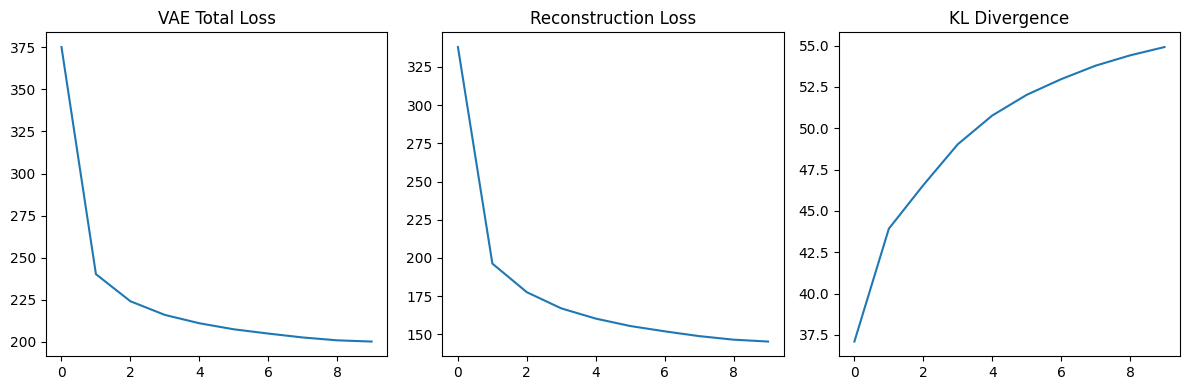


TRAINING GAN FROM SCRATCH
Training GAN for 20 epochs...


GAN Epoch 1/20: 100%|██████████| 391/391 [00:14<00:00, 27.65it/s, D_loss=2.4294, G_loss=0.4731, D(x)=0.3274, D(G(z))=0.6232]


GAN Epoch 1/20 - Time: 14.15s
  D_loss: 2.8909, G_loss: 0.3115
  D(x): 0.3681, D(G(z)): 0.7388


GAN Epoch 2/20: 100%|██████████| 391/391 [00:14<00:00, 27.74it/s, D_loss=1.9273, G_loss=0.7255, D(x)=0.3438, D(G(z))=0.4842]


GAN Epoch 2/20 - Time: 14.10s
  D_loss: 2.0526, G_loss: 0.6238
  D(x): 0.3618, D(G(z)): 0.5383


...

GAN Epoch 18/20 - Time: 13.86s
  D_loss: 1.3963, G_loss: 0.6923
  D(x): 0.4982, D(G(z)): 0.5006


GAN Epoch 19/20: 100%|██████████| 391/391 [00:14<00:00, 27.69it/s, D_loss=1.3878, G_loss=0.7044, D(x)=0.4978, D(G(z))=0.4948]


GAN Epoch 19/20 - Time: 14.12s
  D_loss: 1.3950, G_loss: 0.6942
  D(x): 0.4983, D(G(z)): 0.4997


GAN Epoch 20/20: 100%|██████████| 391/391 [00:13<00:00, 28.08it/s, D_loss=1.3929, G_loss=0.6971, D(x)=0.4974, D(G(z))=0.4983]


GAN Epoch 20/20 - Time: 13.93s
  D_loss: 1.3939, G_loss: 0.6965
  D(x): 0.4980, D(G(z)): 0.4986


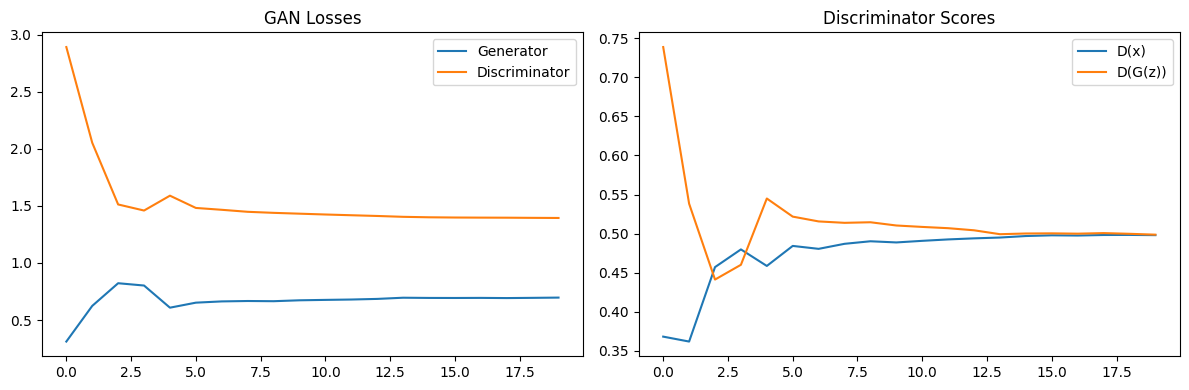


GENERATING RESULTS
Generating VAE reconstructions...
Latent space - Mean: 0.0348, Std: 0.7531
Generating GAN samples...


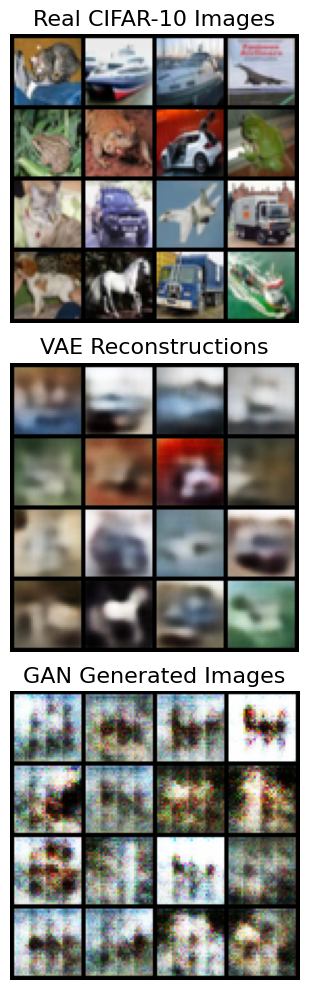


=== Training Completed ===
VAE trained for 10 epochs - should produce blurry but recognizable reconstructions
GAN trained for 20 epochs - should produce diverse generated images


In [60]:
# THIS WILL ALWAYS RETRAIN WHEN YOU RUN THE CELL
if __name__ == "__main__":
    vae_model, gan_model = main()  # Capture the returned models

In [62]:
from torchvision.utils import make_grid

In [63]:
def latent_space_interpolation(vae_model, gan_model, test_loader, num_interpolations=5, steps=10):
    """
    Compare VAE and GAN latent space interpolation
    """
    vae_model.eval()
    gan_model.eval()

    # Get some test images from different classes
    test_iter = iter(test_loader)
    images, labels = next(test_iter)
    images = images.to(device)

    # Find images from different classes
    unique_classes = torch.unique(labels)
    print(f"Found classes: {unique_classes.tolist()}")

    # Select pairs of images from different classes
    class_pairs = []
    for i in range(min(num_interpolations, len(unique_classes)//2)):
        class1 = unique_classes[i*2]
        class2 = unique_classes[i*2 + 1]

        # Get first image from each class
        idx1 = (labels == class1).nonzero()[0]
        idx2 = (labels == class2).nonzero()[0]

        class_pairs.append((images[idx1], images[idx2], class1.item(), class2.item()))

    # CIFAR-10 class names for labeling
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

    # Create interpolation for each pair
    for i, (img1, img2, class1, class2) in enumerate(class_pairs):
        print(f"\nInterpolation {i+1}: {class_names[class1]} → {class_names[class2]}")

        # VAE Interpolation
        print("Generating VAE interpolation...")
        vae_interpolation = vae_latent_interpolation(vae_model, img1, img2, steps)

        # GAN Interpolation
        print("Generating GAN interpolation...")
        gan_interpolation = gan_latent_interpolation(gan_model, img1.shape[0], steps)

        # Plot comparisons
        plot_interpolation_comparison(img1, img2, vae_interpolation, gan_interpolation,
                                    class_names[class1], class_names[class2], i+1)

In [64]:
def vae_latent_interpolation(vae_model, img1, img2, steps=10):
    """Interpolate in VAE latent space"""
    with torch.no_grad():
        # Encode both images to latent space
        mu1, logvar1 = vae_model.encode(img1)
        mu2, logvar2 = vae_model.encode(img2)
        z1 = vae_model.reparameterize(mu1, logvar1)
        z2 = vae_model.reparameterize(mu2, logvar2)

        # Linear interpolation in latent space
        interpolated_images = []
        for alpha in torch.linspace(0, 1, steps):
            z_interp = (1 - alpha) * z1 + alpha * z2
            img_interp = vae_model.decode(z_interp)
            interpolated_images.append(img_interp)

        return torch.cat(interpolated_images)


In [65]:
def gan_latent_interpolation(gan_model, batch_size, steps=10):
    """Interpolate in GAN latent space"""
    with torch.no_grad():
        # Generate two random latent vectors
        z1 = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        z2 = torch.randn(batch_size, latent_dim, 1, 1, device=device)

        # Linear interpolation in latent space
        interpolated_images = []
        for alpha in torch.linspace(0, 1, steps):
            z_interp = (1 - alpha) * z1 + alpha * z2
            img_interp = gan_model(z_interp)
            interpolated_images.append(img_interp)

        return torch.cat(interpolated_images)

In [66]:
def plot_interpolation_comparison(img1, img2, vae_interp, gan_interp, class1_name, class2_name, pair_num):
    """Plot the interpolation comparison"""
    fig, axes = plt.subplots(3, 1, figsize=(15, 8))

    # Original images
    original_grid = make_grid(torch.cat([img1, img2]), nrow=2, normalize=True, padding=10)
    axes[0].imshow(np.transpose(original_grid.cpu().numpy(), (1, 2, 0)))
    axes[0].set_title(f'Original Images: {class1_name} → {class2_name}', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # VAE interpolation
    vae_grid = make_grid(vae_interp, nrow=len(vae_interp), normalize=True, padding=2)
    axes[1].imshow(np.transpose(vae_grid.cpu().numpy(), (1, 2, 0)))
    axes[1].set_title('VAE Latent Space Interpolation', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    # GAN interpolation
    gan_grid = make_grid(gan_interp, nrow=len(gan_interp), normalize=True, padding=2)
    axes[2].imshow(np.transpose(gan_grid.cpu().numpy(), (1, 2, 0)))
    axes[2].set_title('GAN Latent Space Interpolation', fontsize=14, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(f'interpolation_comparison_{pair_num}.png', dpi=150, bbox_inches='tight')
    plt.show()

=== Latent Space Interpolation Analysis ===
This compares how smoothly VAE and GAN transition between images in latent space
VAE uses real image encodings, GAN uses random latent vectors
Found classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Interpolation 1: airplane → automobile
Generating VAE interpolation...
Generating GAN interpolation...


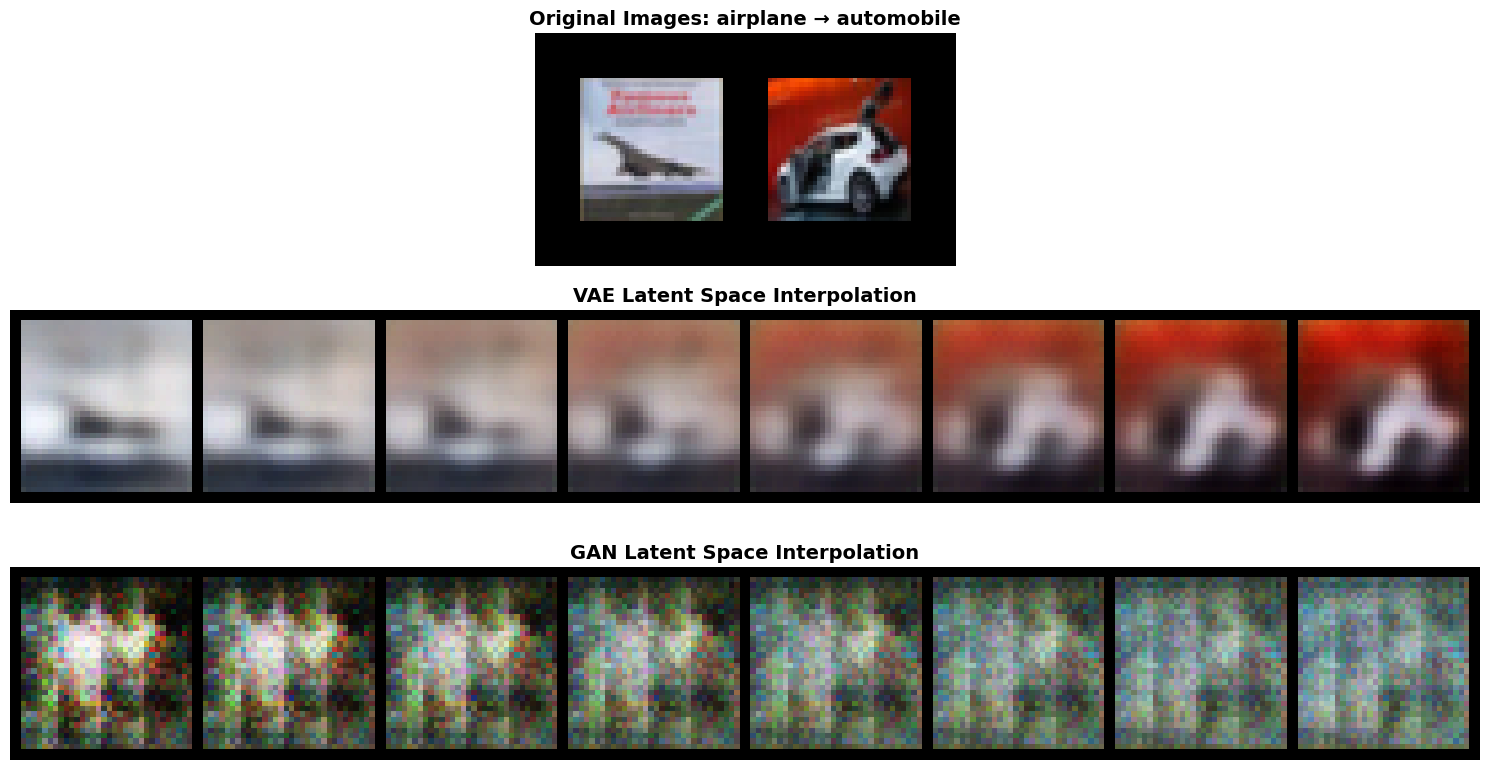


Observations:
- VAE: Should show smooth, gradual transitions between images
- GAN: May show smoother transitions or abrupt changes
- Look for coherence in intermediate images

Interpolation 2: bird → cat
Generating VAE interpolation...
Generating GAN interpolation...


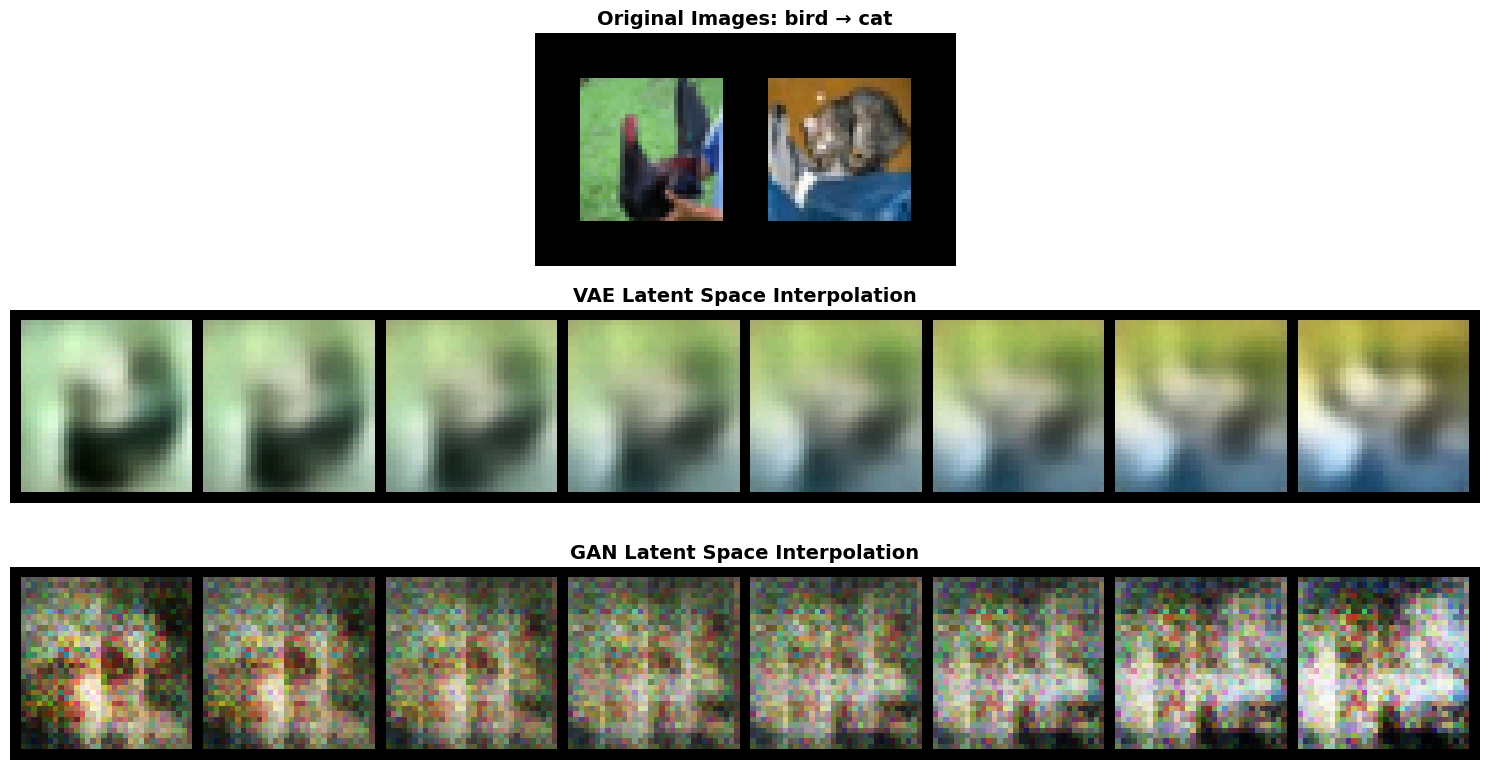


Observations:
- VAE: Should show smooth, gradual transitions between images
- GAN: May show smoother transitions or abrupt changes
- Look for coherence in intermediate images

Interpolation 3: deer → dog
Generating VAE interpolation...
Generating GAN interpolation...


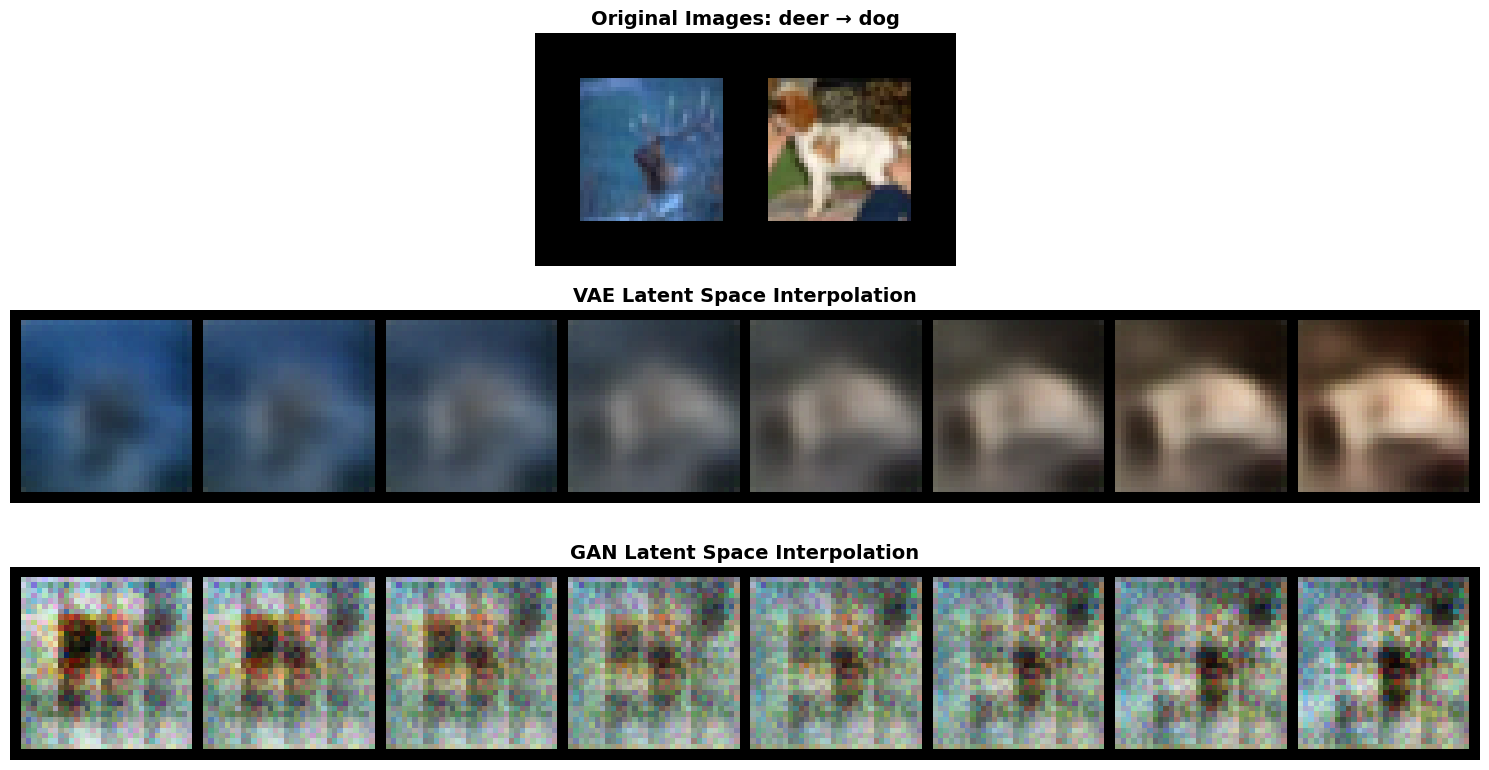


Observations:
- VAE: Should show smooth, gradual transitions between images
- GAN: May show smoother transitions or abrupt changes
- Look for coherence in intermediate images

ANALYSIS GUIDE:

WHAT TO OBSERVE:

VAE INTERPOLATION:
- Smooth, gradual transitions between images
- Intermediate images should look plausible (not blurry mess)
- Shows continuous latent space structure

GAN INTERPOLATION:
- May be smooth or show abrupt changes
- Intermediate images might be less coherent
- Tests if GAN learned a continuous manifold

KEY COMPARISON:
- Which has smoother transitions?
- Which produces more realistic intermediate images?
- Which better preserves semantic meaning throughout interpolation?



In [67]:
latent_space_interpolation(vae_model, gan_model, test_loader, num_interpolations=3, steps=8)

In [68]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [69]:
def vae_latent_analysis(vae_model, test_loader, num_samples=200):
    """
    Analyze VAE latent space structure
    """
    print("=== VAE Latent Space Analysis ===")

    vae_model.eval()

    # Collect latent vectors and labels
    latent_vectors = []
    labels_list = []

    with torch.no_grad():
        for i, (images, labels) in enumerate(test_loader):
            if len(latent_vectors) >= num_samples:
                break

            images = images.to(device)
            mu, logvar = vae_model.encode(images)

            latent_vectors.append(mu.cpu())
            labels_list.append(labels)

    latent_vectors = torch.cat(latent_vectors)[:num_samples]
    labels = torch.cat(labels_list)[:num_samples]

    print(f"Collected {len(latent_vectors)} latent vectors")
    print(f"Latent space dimension: {latent_vectors.shape[1]}")

    # 1. PCA Visualization
    print("\n1. PCA Visualization of Latent Space")
    plot_latent_pca(latent_vectors.numpy(), labels.numpy())

    # 2. t-SNE Visualization
    print("\n2. t-SNE Visualization of Latent Space")
    plot_latent_tsne(latent_vectors.numpy(), labels.numpy())

    # 3. Semantic Factor Analysis
    print("\n3. Semantic Factor Analysis")
    analyze_semantic_factors(vae_model, latent_vectors)


In [70]:
def plot_latent_pca(latent_vectors, labels):
    """Plot PCA of latent space"""
    # Reduce to 2D using PCA
    pca = PCA(n_components=2)
    latent_2d = pca.fit_transform(latent_vectors)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels,
                         cmap='tab10', alpha=0.6, s=20)
    plt.colorbar(scatter, label='Class Labels')
    plt.title('VAE Latent Space - PCA Visualization')
    plt.xlabel('PC1 ({:.1f}% variance)'.format(pca.explained_variance_ratio_[0]*100))
    plt.ylabel('PC2 ({:.1f}% variance)'.format(pca.explained_variance_ratio_[1]*100))
    plt.grid(alpha=0.3)
    plt.savefig('vae_latent_pca.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")


In [71]:
def plot_latent_tsne(latent_vectors, labels):
    """Plot t-SNE of latent space"""
    # Use t-SNE for non-linear dimensionality reduction
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    latent_2d = tsne.fit_transform(latent_vectors)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels,
                         cmap='tab10', alpha=0.6, s=20)
    plt.colorbar(scatter, label='Class Labels')
    plt.title('VAE Latent Space - t-SNE Visualization')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(alpha=0.3)
    plt.savefig('vae_latent_tsne.png', dpi=150, bbox_inches='tight')
    plt.show()

In [72]:
def analyze_semantic_factors(vae_model, latent_vectors):
    """Analyze if specific latent dimensions have semantic meaning"""
    print("\nAnalyzing semantic factors in latent dimensions...")

    # Use mean latent vector as starting point
    mean_latent = latent_vectors.mean(dim=0)

    # Test variation along each of the first 5 dimensions
    num_dims_to_test = min(5, latent_vectors.shape[1])

    fig, axes = plt.subplots(num_dims_to_test, 11, figsize=(15, 2*num_dims_to_test))

    for dim in range(num_dims_to_test):
        print(f"Testing dimension {dim}...")

        # Generate images by varying this dimension
        variations = []
        for val in torch.linspace(-3, 3, 11):  # Vary from -3 to +3 std
            modified_latent = mean_latent.clone()
            modified_latent[dim] = val
            variations.append(modified_latent)

        variations = torch.stack(variations).to(device)

        with torch.no_grad():
            generated_images = vae_model.decode(variations)

        # Plot the variations
        for i, img in enumerate(generated_images):
            if num_dims_to_test == 1:
                ax = axes[i]
            else:
                ax = axes[dim, i]

            ax.imshow(np.transpose(img.cpu().numpy(), (1, 2, 0)) * 0.5 + 0.5)  # Unnormalize
            ax.axis('off')

            if i == 0:
                if num_dims_to_test == 1:
                    ax.set_title(f'Dim {dim}\n-3', fontsize=8)
                else:
                    ax.set_ylabel(f'Dim {dim}', rotation=0, ha='right', fontsize=10)
            if i == 5:
                ax.set_title('0', fontsize=8)
            if i == 10:
                ax.set_title('+3', fontsize=8)

    plt.suptitle('Semantic Factor Analysis: Varying Individual Latent Dimensions', fontsize=14)
    plt.tight_layout()
    plt.savefig('vae_semantic_factors.png', dpi=150, bbox_inches='tight')
    plt.show()




In [73]:
# CIFAR-10 class names for reference
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


Starting VAE latent space analysis...
=== VAE Latent Space Analysis ===
Collected 200 latent vectors
Latent space dimension: 128

1. PCA Visualization of Latent Space


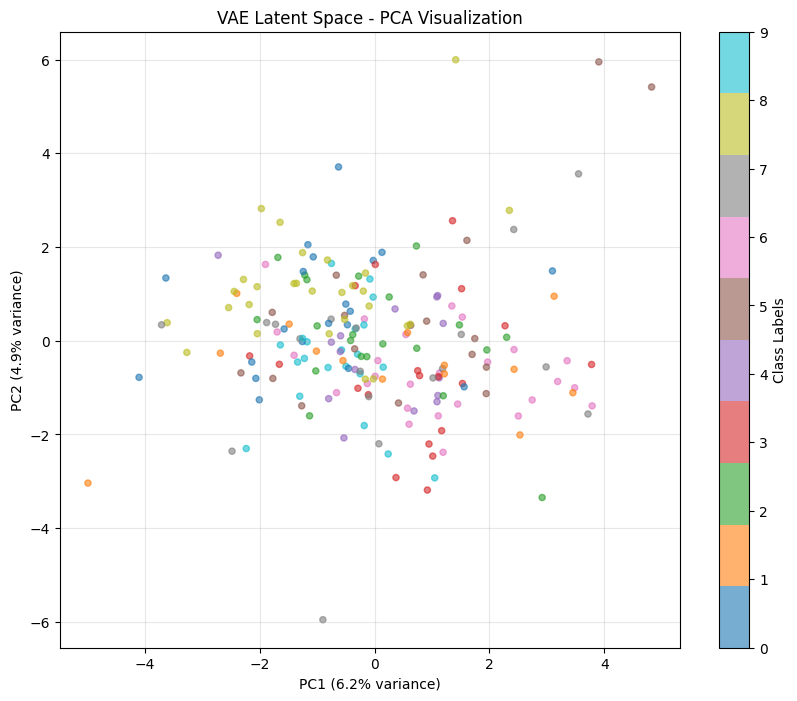

PCA explained variance: 0.111

2. t-SNE Visualization of Latent Space


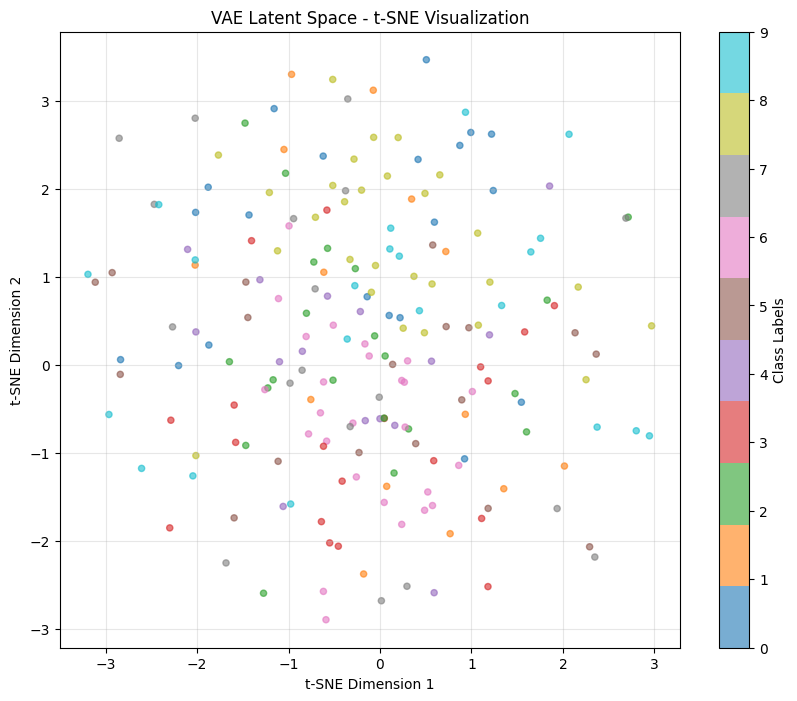


3. Semantic Factor Analysis

Analyzing semantic factors in latent dimensions...
Testing dimension 0...
Testing dimension 1...
Testing dimension 2...
Testing dimension 3...
Testing dimension 4...


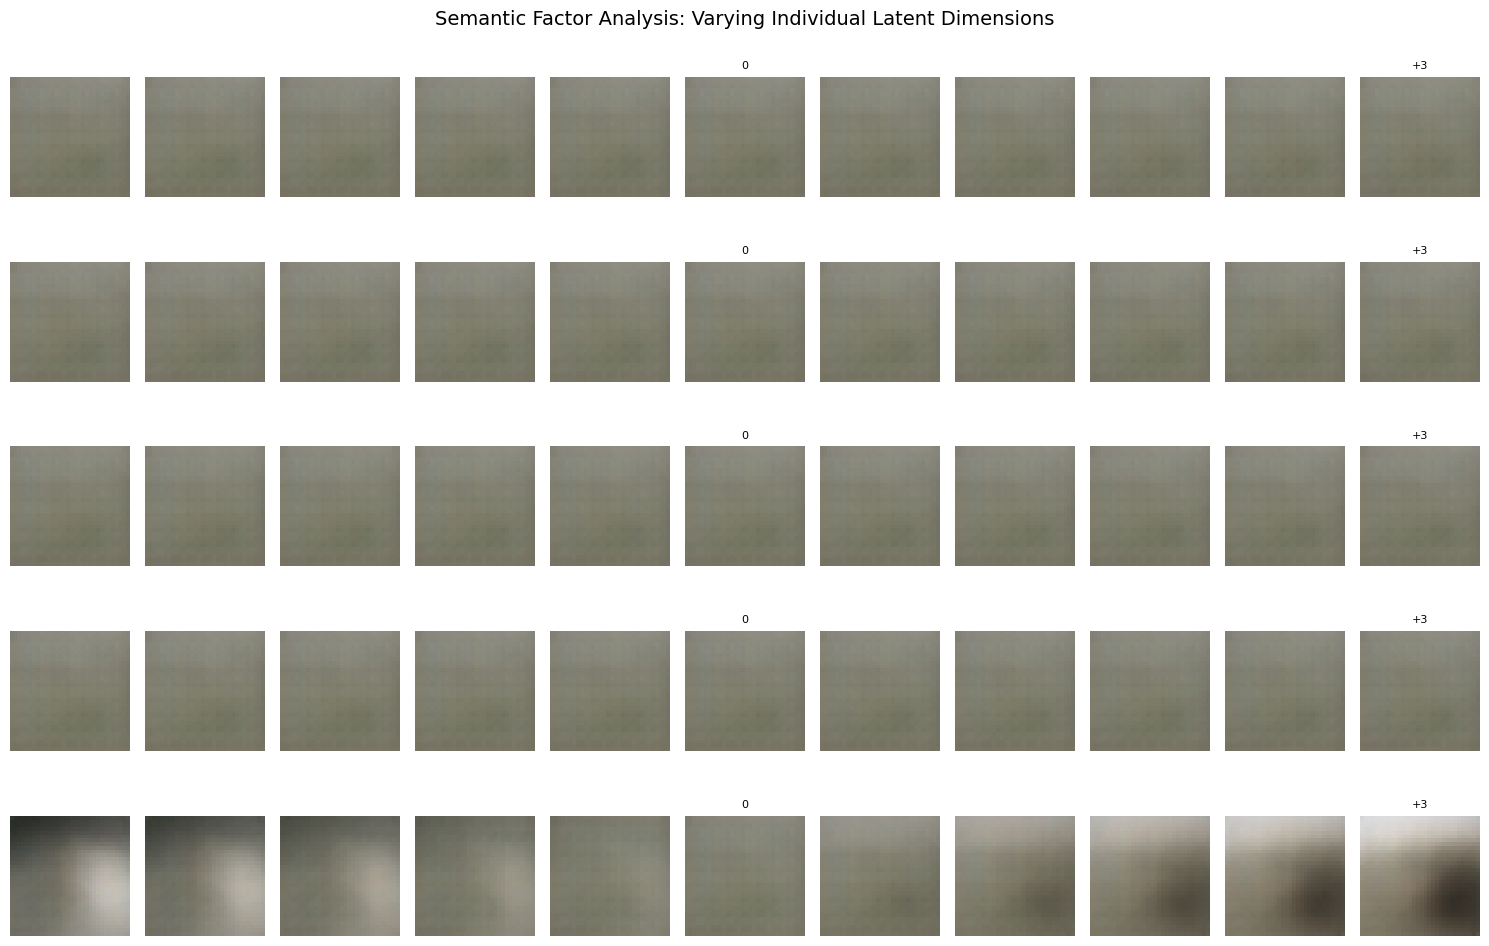


Look for dimensions that consistently change:
- Color (brightness, hue shifts)
- Object size or position
- Background/foreground changes
- Texture patterns


In [74]:
# Run the analysis
print("Starting VAE latent space analysis...")
vae_latent_analysis(vae_model, test_loader, num_samples=200)

In [77]:
def vae_ood_analysis(vae_model, test_loader):
    """
    Analyze VAE reconstruction on Out-of-Distribution images
    """
    print("=== VAE Out-of-Distribution Analysis ===")

    vae_model.eval()

    # Load OOD datasets
    print("Loading OOD datasets...")
    ood_datasets = load_ood_datasets()

    # Test on different types of images
    results = {}

    # 1. Normal CIFAR-10 images (in-distribution)
    print("\n1. Testing on CIFAR-10 (in-distribution)...")
    normal_images, normal_recons, normal_errors = test_reconstruction(vae_model, test_loader, num_samples=8)
    results['cifar10'] = {'images': normal_images, 'recons': normal_recons, 'errors': normal_errors}

    # 2. CIFAR-100 images (similar but OOD)
    print("2. Testing on CIFAR-100 (out-of-distribution)...")
    cifar100_results = test_ood_reconstruction(vae_model, ood_datasets['cifar100'], "CIFAR-100")
    results['cifar100'] = cifar100_results

    # 3. SVHN digits (very different OOD)
    print("3. Testing on SVHN digits (very out-of-distribution)...")
    svhn_results = test_ood_reconstruction(vae_model, ood_datasets['svhn'], "SVHN")
    results['svhn'] = svhn_results

    # 4. Simple geometric shapes (completely OOD)
    print("4. Testing on geometric shapes (completely out-of-distribution)...")
    shapes_results = test_synthetic_shapes(vae_model)
    results['shapes'] = shapes_results

    # Visualize all results
    print("\nGenerating comparison visualizations...")
    visualize_ood_comparison(results)

    # Print analysis
    print_ood_analysis(results)

In [78]:
def load_ood_datasets():
    """Load out-of-distribution datasets"""
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    ood_datasets = {}

    try:
        # CIFAR-100 (similar domain but different classes)
        cifar100_test = torchvision.datasets.CIFAR100(root='./data', train=False,
                                                     download=True, transform=transform)
        ood_datasets['cifar100'] = torch.utils.data.DataLoader(cifar100_test, batch_size=8, shuffle=True)
    except:
        print("Could not load CIFAR-100")

    try:
        # SVHN digits (very different domain)
        svhn_test = torchvision.datasets.SVHN(root='./data', split='test',
                                            download=True, transform=transform)
        ood_datasets['svhn'] = torch.utils.data.DataLoader(svhn_test, batch_size=8, shuffle=True)
    except:
        print("Could not load SVHN")

    return ood_datasets

In [79]:
def test_reconstruction(vae_model, data_loader, num_samples=8):
    """Test reconstruction on a dataset"""
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    images = images[:num_samples].to(device)

    with torch.no_grad():
        reconstructions, _, _ = vae_model(images)
        errors = torch.mean((images - reconstructions) ** 2, dim=[1,2,3])  # MSE per image

    return images.cpu(), reconstructions.cpu(), errors.cpu()

In [80]:
def test_ood_reconstruction(vae_model, data_loader, dataset_name):
    """Test reconstruction on OOD dataset"""
    if data_loader is None:
        return None

    try:
        data_iter = iter(data_loader)
        images, labels = next(data_iter)
        images = images.to(device)

        with torch.no_grad():
            reconstructions, _, _ = vae_model(images)
            errors = torch.mean((images - reconstructions) ** 2, dim=[1,2,3])

        return {'images': images.cpu(), 'recons': reconstructions.cpu(), 'errors': errors.cpu()}
    except:
        print(f"Error processing {dataset_name}")
        return None

In [81]:
def test_synthetic_shapes(vae_model):
    """Generate synthetic geometric shapes"""
    synthetic_images = []

    for i in range(8):
        # Create simple geometric shapes
        img = torch.zeros(3, 32, 32)

        if i % 4 == 0:  # Rectangle
            img[:, 8:24, 8:24] = 1.0
        elif i % 4 == 1:  # Circle
            y, x = np.ogrid[-16:16, -16:16]
            mask = x*x + y*y <= 10*10
            img[:, mask] = 1.0
        elif i % 4 == 2:  # Triangle
            for j in range(16):
                img[:, 16-j:16+j, 24-j] = 1.0
        else:  # Cross
            img[:, 8:24, 16:17] = 1.0
            img[:, 16:17, 8:24] = 1.0

        synthetic_images.append(img)

    synthetic_images = torch.stack(synthetic_images)
    synthetic_images = synthetic_images * 2 - 1  # Scale to [-1, 1]
    synthetic_images = synthetic_images.to(device)

    with torch.no_grad():
        reconstructions, _, _ = vae_model(synthetic_images)
        errors = torch.mean((synthetic_images - reconstructions) ** 2, dim=[1,2,3])

    return {'images': synthetic_images.cpu(), 'recons': reconstructions.cpu(), 'errors': errors.cpu()}

In [82]:
def visualize_ood_comparison(results):
    """Create comprehensive visualization of OOD results"""
    fig, axes = plt.subplots(4, 3, figsize=(15, 12))

    datasets = ['cifar10', 'cifar100', 'svhn', 'shapes']
    titles = ['CIFAR-10 (In-Distribution)', 'CIFAR-100 (OOD)', 'SVHN Digits (OOD)', 'Geometric Shapes (OOD)']

    for i, (dataset, title) in enumerate(zip(datasets, titles)):
        if dataset in results and results[dataset] is not None:
            data = results[dataset]

            # Original images
            orig_grid = make_grid(data['images'], nrow=8, normalize=True, padding=2)
            axes[i, 0].imshow(np.transpose(orig_grid.numpy(), (1, 2, 0)))
            axes[i, 0].set_title(f'{title}\nOriginal', fontweight='bold')
            axes[i, 0].axis('off')

            # Reconstructions
            recon_grid = make_grid(data['recons'], nrow=8, normalize=True, padding=2)
            axes[i, 1].imshow(np.transpose(recon_grid.numpy(), (1, 2, 0)))
            axes[i, 1].set_title('VAE Reconstruction', fontweight='bold')
            axes[i, 1].axis('off')

            # Error visualization
            error_imgs = torch.abs(data['images'] - data['recons'])
            error_grid = make_grid(error_imgs, nrow=8, normalize=True, padding=2)
            axes[i, 2].imshow(np.transpose(error_grid.numpy(), (1, 2, 0)))
            axes[i, 2].set_title(f'Error Map\nAvg MSE: {data["errors"].mean():.4f}', fontweight='bold')
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.savefig('vae_ood_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()


In [83]:
def print_ood_analysis(results):
    """Print quantitative analysis"""
    print("\n" + "="*60)
    print("OOD RECONSTRUCTION ANALYSIS")
    print("="*60)

    for dataset_name in ['cifar10', 'cifar100', 'svhn', 'shapes']:
        if dataset_name in results and results[dataset_name] is not None:
            errors = results[dataset_name]['errors']
            print(f"{dataset_name.upper():<12} - Average MSE: {errors.mean():.4f} ± {errors.std():.4f}")


Starting VAE Out-of-Distribution analysis...
=== VAE Out-of-Distribution Analysis ===
Loading OOD datasets...

1. Testing on CIFAR-10 (in-distribution)...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


2. Testing on CIFAR-100 (out-of-distribution)...
3. Testing on SVHN digits (very out-of-distribution)...
4. Testing on geometric shapes (completely out-of-distribution)...

Generating comparison visualizations...


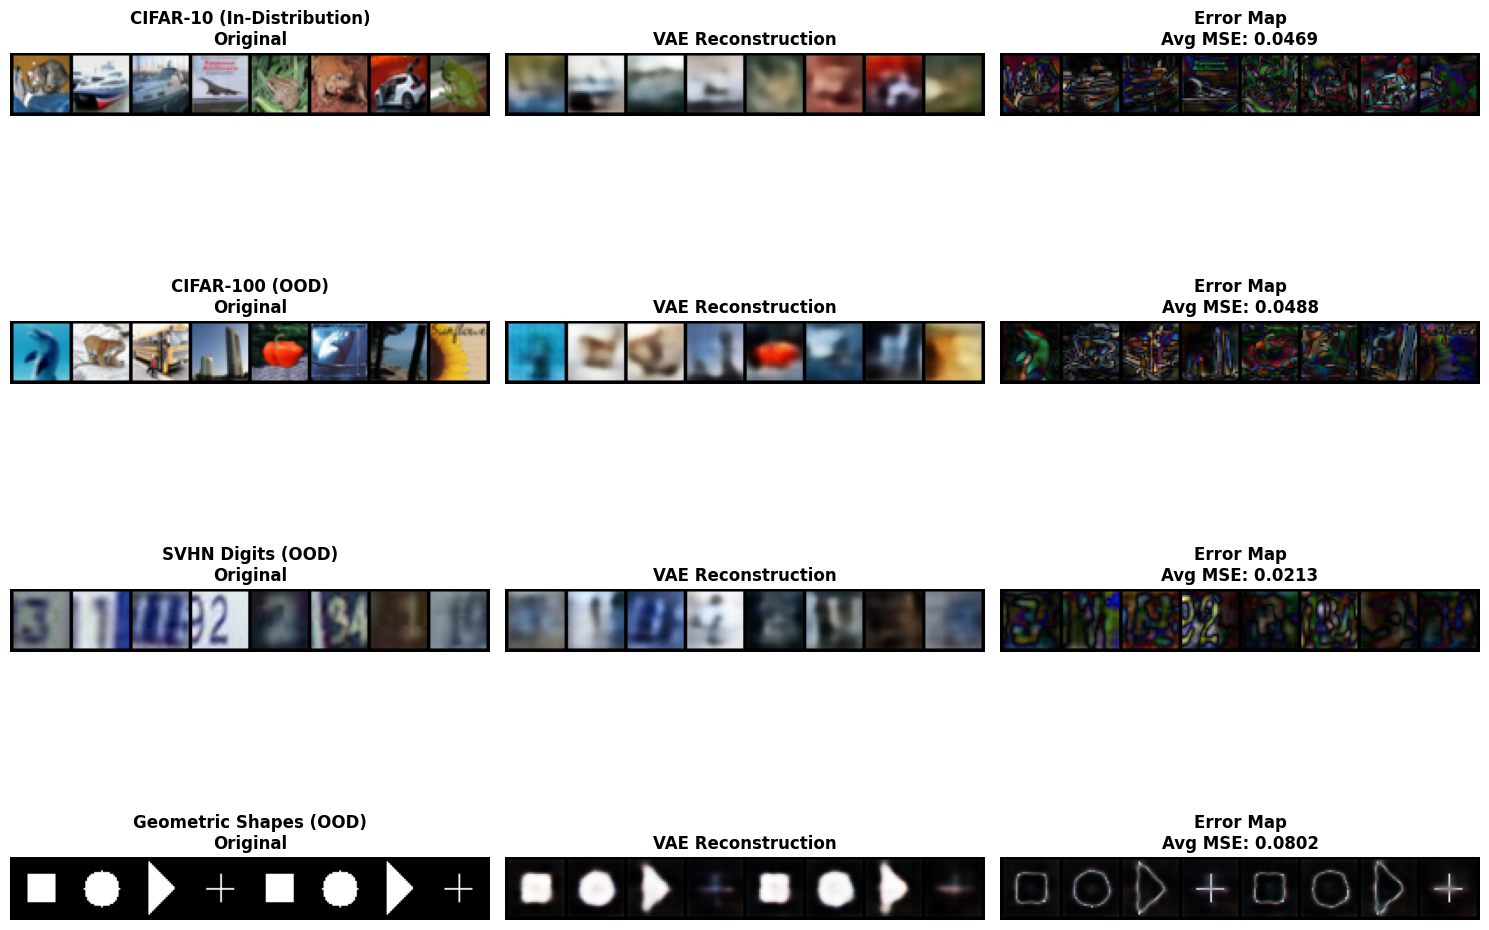


OOD RECONSTRUCTION ANALYSIS
CIFAR10      - Average MSE: 0.0469 ± 0.0158
CIFAR100     - Average MSE: 0.0488 ± 0.0124
SVHN         - Average MSE: 0.0213 ± 0.0137
SHAPES       - Average MSE: 0.0802 ± 0.0165

KEY OBSERVATIONS TO NOTE:

1. RECONSTRUCTION BEHAVIOR:
   - In-distribution (CIFAR-10): Should reconstruct well
   - OOD images: VAE will 'project' them onto training manifold
   - Look for: shapes turning into animals/vehicles, digits becoming blobs

2. ERROR PATTERNS:
   - OOD images should have higher reconstruction error
   - Error maps show where VAE struggles most

3. MANIFOLD PROJECTION:
   - VAE assumes all inputs are from training distribution
   - OOD inputs get 'interpreted' as nearest training examples
   - This shows the inductive bias of the latent prior



In [84]:
# Run the OOD analysis
print("Starting VAE Out-of-Distribution analysis...")
vae_ood_analysis(vae_model, test_loader)

In [85]:
def gan_ood_extrapolation(gan_model, num_samples=16):
    """
    Test GAN on out-of-distribution latent vectors (extrapolation)
    """
    print("=== GAN Out-of-Distribution Analysis ===")
    print("Testing GAN on latent vectors outside training distribution...")

    gan_model.eval()

    results = {}

    # 1. Normal latent vectors (in-distribution)
    print("\n1. Normal latent vectors (N(0,1))...")
    normal_latents = torch.randn(num_samples, latent_dim, 1, 1, device=device)
    with torch.no_grad():
        normal_images = gan_model(normal_latents)
    results['normal'] = {'latents': normal_latents, 'images': normal_images}

    # 2. Large magnitude latent vectors (OOD)
    print("2. Large magnitude latent vectors (N(0,5))...")
    large_latents = torch.randn(num_samples, latent_dim, 1, 1, device=device) * 5.0
    with torch.no_grad():
        large_images = gan_model(large_latents)
    results['large'] = {'latents': large_latents, 'images': large_images}

    # 3. Very large magnitude latent vectors (extreme OOD)
    print("3. Very large magnitude latent vectors (N(0,10))...")
    extreme_latents = torch.randn(num_samples, latent_dim, 1, 1, device=device) * 10.0
    with torch.no_grad():
        extreme_images = gan_model(extreme_latents)
    results['extreme'] = {'latents': extreme_latents, 'images': extreme_images}

    # 4. Uniform distribution (completely different distribution)
    print("4. Uniform distribution (U(-3,3))...")
    uniform_latents = torch.rand(num_samples, latent_dim, 1, 1, device=device) * 6 - 3
    with torch.no_grad():
        uniform_images = gan_model(uniform_latents)
    results['uniform'] = {'latents': uniform_latents, 'images': uniform_images}

    # Visualize results
    visualize_gan_ood(results)

    return results


In [86]:
def visualize_gan_ood(results):
    """Visualize GAN OOD extrapolation results"""
    fig, axes = plt.subplots(4, 2, figsize=(12, 16))

    test_cases = [
        ('normal', 'Normal Latents\nN(0,1) - In Distribution'),
        ('large', 'Large Latents\nN(0,5) - Mild OOD'),
        ('extreme', 'Extreme Latents\nN(0,10) - Severe OOD'),
        ('uniform', 'Uniform Latents\nU(-3,3) - Different Distribution')
    ]

    for i, (case_key, title) in enumerate(test_cases):
        if case_key in results:
            images = results[case_key]['images']
            latents = results[case_key]['latents']

            # Show generated images
            img_grid = make_grid(images.cpu(), nrow=4, normalize=True, padding=2)
            axes[i, 0].imshow(np.transpose(img_grid.numpy(), (1, 2, 0)))
            axes[i, 0].set_title(f'{title}\nGenerated Images', fontweight='bold')
            axes[i, 0].axis('off')

            # Show latent vector statistics
            latent_norms = torch.norm(latents.view(latents.size(0), -1), dim=1)
            axes[i, 1].hist(latent_norms.cpu().numpy(), bins=10, alpha=0.7, color='skyblue')
            axes[i, 1].set_title(f'Latent Vector Norms\nMean: {latent_norms.mean():.2f} ± {latent_norms.std():.2f}')
            axes[i, 1].set_xlabel('Latent Vector Norm')
            axes[i, 1].set_ylabel('Frequency')
            axes[i, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('gan_ood_extrapolation.png', dpi=150, bbox_inches='tight')
    plt.show()


Testing GAN on out-of-distribution latent vectors...
=== GAN Out-of-Distribution Analysis ===
Testing GAN on latent vectors outside training distribution...

1. Normal latent vectors (N(0,1))...
2. Large magnitude latent vectors (N(0,5))...
3. Very large magnitude latent vectors (N(0,10))...
4. Uniform distribution (U(-3,3))...


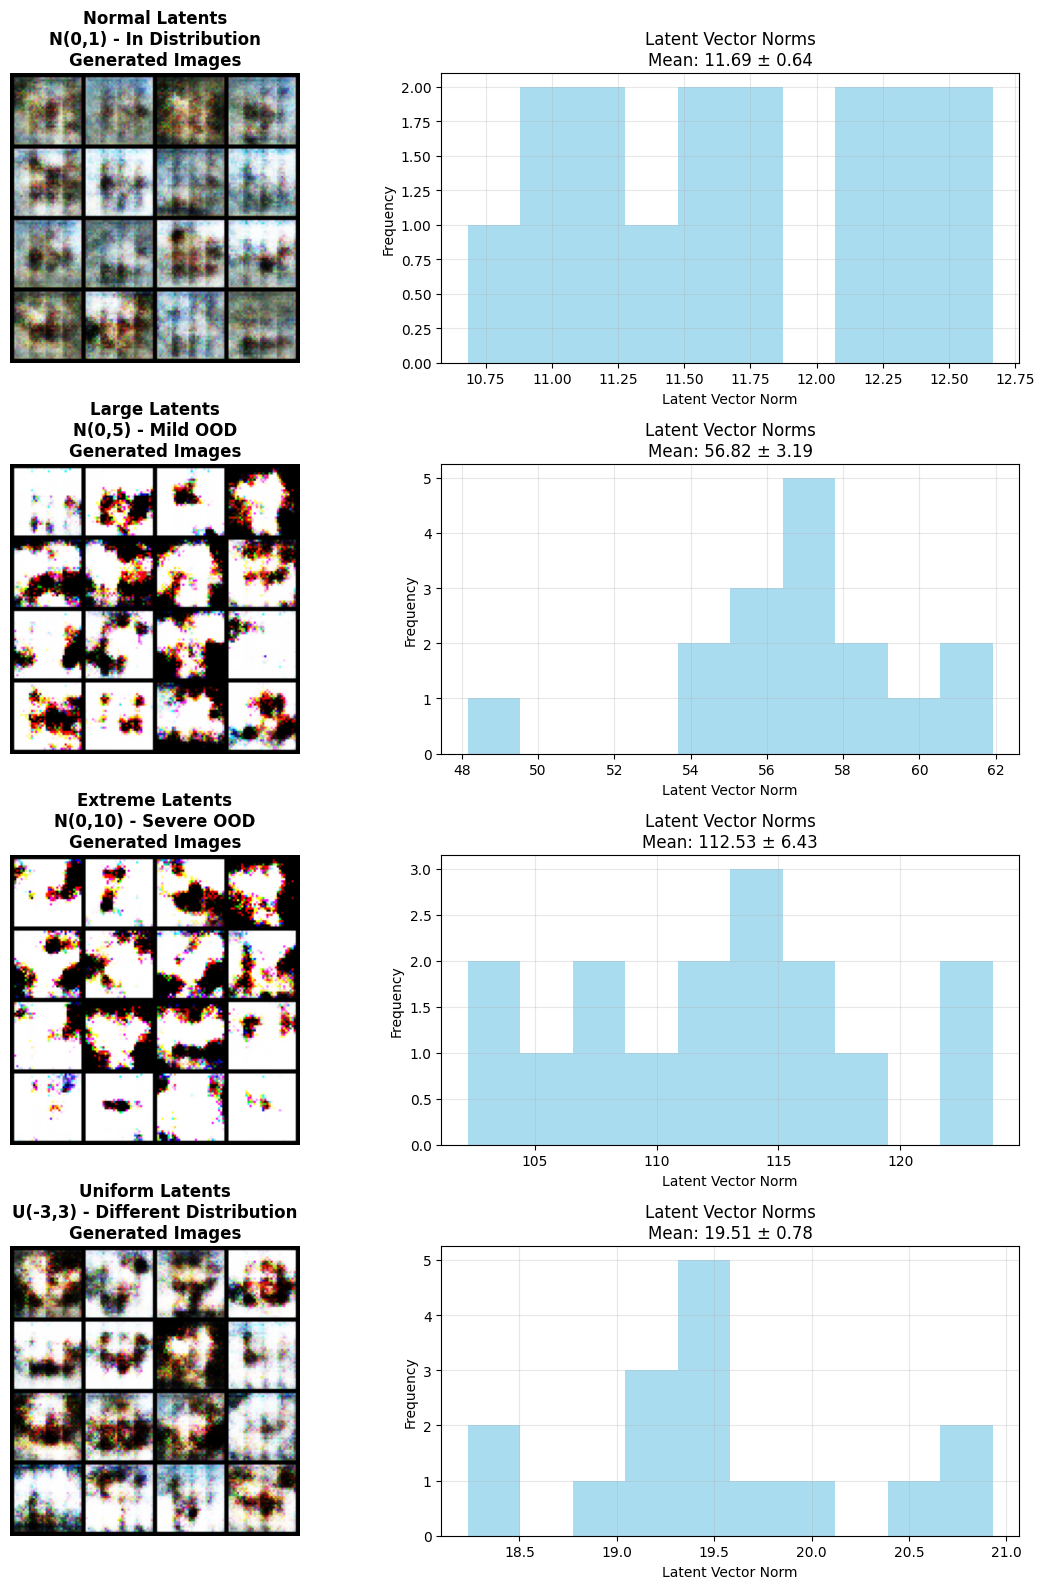


GAN OOD EXTRAPOLATION ANALYSIS

WHAT TO OBSERVE:
1. NORMAL LATENTS (N(0,1)): Should produce clean, diverse CIFAR-10-like images
2. LARGE LATENTS (N(0,5)): Images may become distorted or oversaturated
3. EXTREME LATENTS (N(0,10)): Likely complete degradation - noise or artifacts
4. UNIFORM LATENTS (U(-3,3)): May produce different style due to distribution shift

KEY INSIGHTS:
- GANs are only trained on standard normal latent vectors
- Extrapolation tests generalization beyond training distribution
- Poor OOD performance shows limited latent space understanding
- Good OOD performance indicates robust latent manifold learning

INTERPRETATION GUIDE:

GOOD SIGNS:
- Mild OOD latents still produce recognizable images
- Gradual degradation rather than complete collapse
- Some robustness to distribution shifts

POOR SIGNS:  
- Immediate collapse with any deviation from N(0,1)
- Complete noise or meaningless patterns
- Extreme sensitivity to latent vector scale

TYPICAL BEHAVIOR:
- GANs usually

In [88]:
# Run GAN OOD analysis
print("Testing GAN on out-of-distribution latent vectors...")
gan_ood_results = gan_ood_extrapolation(gan_model)

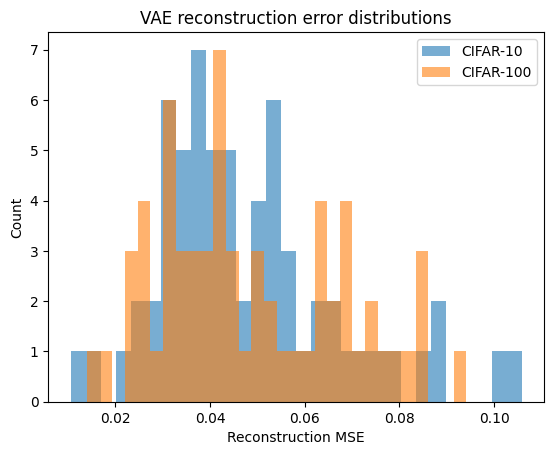

Mean MSE CIFAR-10: 0.048108428716659546
Mean MSE CIFAR-100: 0.048944324254989624


In [89]:
cifar10_loader = DataLoader(
    torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform),
    batch_size=64, shuffle=True
)
cifar100_loader = DataLoader(
    torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=transform),
    batch_size=64, shuffle=True
)

c10_imgs, _ = next(iter(cifar10_loader))
c100_imgs, _ = next(iter(cifar100_loader))

c10_imgs, c100_imgs = c10_imgs.to(device), c100_imgs.to(device)

with torch.no_grad():
    c10_recon, _, _ = vae_model(c10_imgs)
    c100_recon, _, _ = vae_model(c100_imgs)

mse_c10 = F.mse_loss(c10_recon, c10_imgs, reduction="none").view(len(c10_imgs), -1).mean(dim=1)
mse_c100 = F.mse_loss(c100_recon, c100_imgs, reduction="none").view(len(c100_imgs), -1).mean(dim=1)

plt.hist(mse_c10.cpu().numpy(), bins=30, alpha=0.6, label="CIFAR-10")
plt.hist(mse_c100.cpu().numpy(), bins=30, alpha=0.6, label="CIFAR-100")
plt.xlabel("Reconstruction MSE")
plt.ylabel("Count")
plt.legend()
plt.title("VAE reconstruction error distributions")
plt.show()

print("Mean MSE CIFAR-10:", mse_c10.mean().item())
print("Mean MSE CIFAR-100:", mse_c100.mean().item())
